### **SVM**

**Support Vector Machine (SVM)**

Support vector machines (SVMs) are powerful yet flexible supervised machine learning algorithm which is used for both classification and regression. But generally, they are used in classification problems. In 1960s, SVMs were first introduced but later they got refined in 1990 also. SVMs have their unique way of implementation as compared to other machine learning algorithms. Now a days, they are extremely popular because of their ability to handle multiple continuous and categorical variables.

**Working of SVM**

The goal of SVM is to find a hyperplane that separates the data points into different classes. A hyperplane is a line in 2D space, a plane in 3D space, or a higher-dimensional surface in n-dimensional space. The hyperplane is chosen in such a way that it maximizes the margin, which is the distance between the hyperplane and the closest data points of each class. The closest data points are called the support vectors.

The distance between the hyperplane and a data point "x" can be calculated using the formula 

distance = (w . x + b) / ||w|| 

where "w" is the weight vector, "b" is the bias term, and "||w||" is the Euclidean norm of the weight vector. The weight vector "w" is perpendicular to the hyperplane and determines its orientation, while the bias term "b" determines its position.

The optimal hyperplane is found by solving an optimization problem, which is to maximize the margin subject to the constraint that all data points are correctly classified. In other words, we want to find the hyperplane that maximizes the margin between the two classes while ensuring that no data point is misclassified. This is a convex optimization problem that can be solved using quadratic programming.

If the data points are not linearly separable, we can use a technique called kernel trick to map the data points into a higher-dimensional space where they become separable. The kernel function computes the inner product between the mapped data points without computing the mapping itself. This allows us to work with the data points in the higherdimensional space without incurring the computational cost of mapping them.

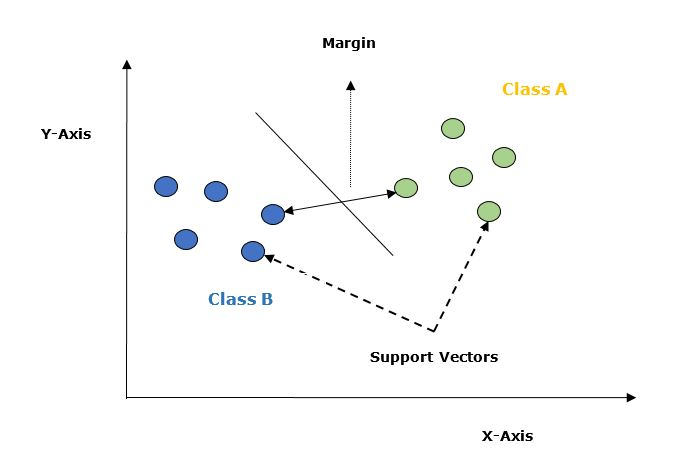

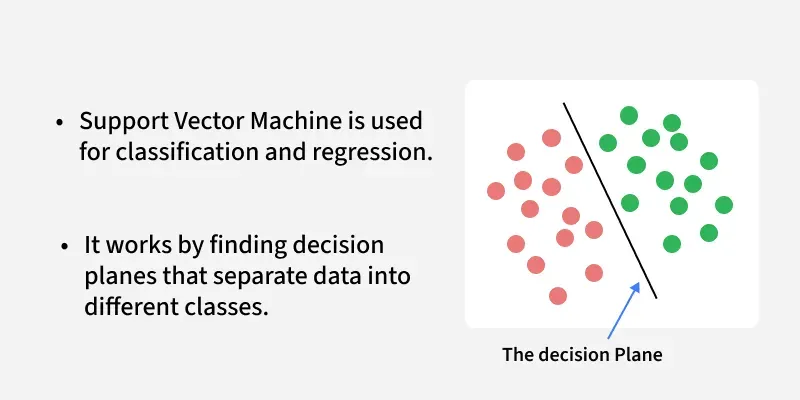

**Components of SVM**

**Support Vectors** − Datapoints that are closest to the hyperplane is called support vectors. Separating line will be defined with the help of these data points.

**Hyperplane** − As we can see in the above diagram it is a decision plane or space which is divided between a set of objects having different classes.

**Margin** − It may be defined as the gap between two lines on the closet data points of different classes. It can be calculated as the perpendicular distance from the line to the support vectors. Large margin is considered as a good margin and small margin is considered as a bad margin.

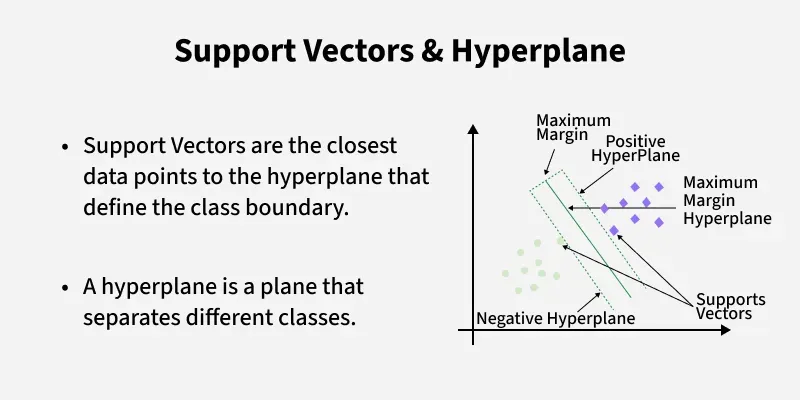

**Kernel:** A function that maps data to a higher-dimensional space enabling SVM to handle non-linearly separable data.

**Hard Margin:** A maximum-margin hyperplane that perfectly separates the data without misclassifications.

**Soft Margin:** Allows some misclassifications by introducing slack variables, balancing margin maximization and misclassification penalties when data is not perfectly separable.

**C:** A regularization term balancing margin maximization and misclassification penalties. A higher C value forces stricter penalty for misclassifications.

**Hinge Loss:** A loss function penalizing misclassified points or margin violations and is combined with regularization in SVM.

**Dual Problem:** Involves solving for Lagrange multipliers associated with support vectors, facilitating the kernel trick and efficient computation.

**Kernel:** A kernel helps us find a hyperplane in the higher dimensional space without increasing the computational cost. Usually, the computational cost will increase if the dimension of the data increases. This increase in dimension is required when we are unable to find a separating hyperplane in a given dimension and are required to move in a higher dimension:


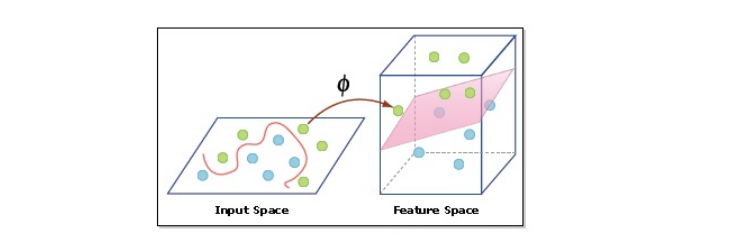

**Linear Kernel**

It can be used as a dot product between any two observations. The formula of linear kernel is as below −

k(x,xi) = sum(x*xi)

From the above formula, we can see that the product between two vectors say & is the sum of the multiplication of each pair of input values.

**Polynomial Kernel**

It is more generalized form of linear kernel and distinguish curved or nonlinear input space. Following is the formula for polynomial kernel −

K(x, xi) = 1 + sum(x * xi)^d

Here d is the degree of polynomial, which we need to specify manually in the learning algorithm.



**Radial Basis Function (RBF) Kernel**

RBF kernel, mostly used in SVM classification, maps input space in indefinite dimensional space. Following formula explains it mathematically −

K(x,xi) = exp(-gamma * sum((x xi^2))

Here, gamma ranges from 0 to 1. We need to manually specify it in the learning algorithm. A good default value of gamma is 0.1.

As we implemented SVM for linearly separable data, we can implement it in Python for the data that is not linearly separable. It can be done by using kernels.

**How does Support Vector Machine Algorithm Work?**

The key idea behind the SVM algorithm is to find the hyperplane that best separates two classes by maximizing the margin between them. This margin is the distance from the hyperplane to the nearest data points (support vectors) on each side.

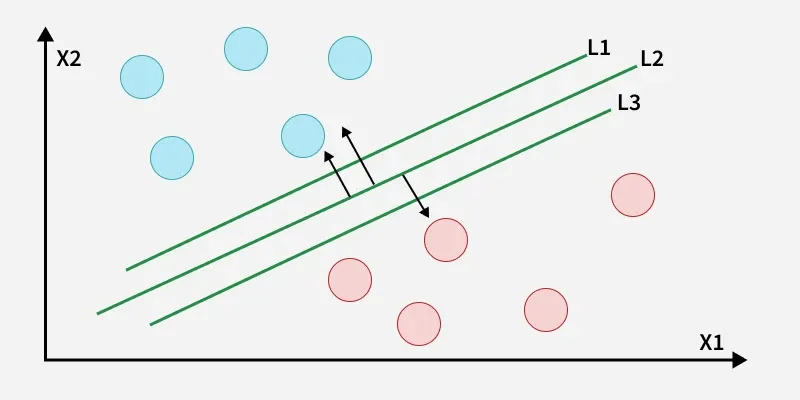

The best hyperplane also known as the "hard margin" is the one that maximizes the distance between the hyperplane and the nearest data points from both classes. This ensures a clear separation between the classes. So from the above figure, we choose L2 as hard margin. Let's consider a scenario like shown below:

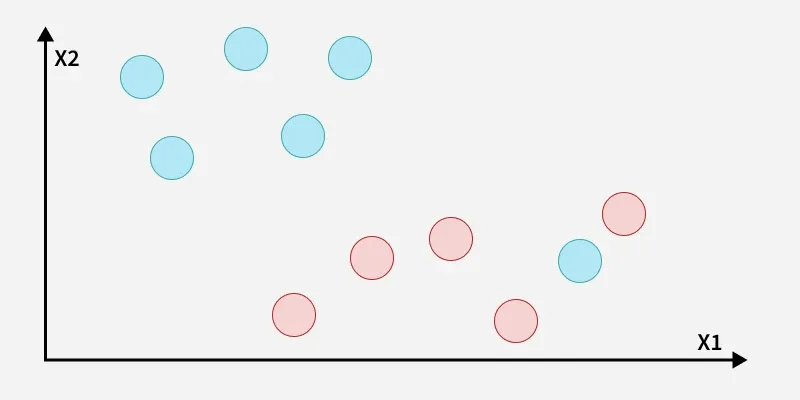

Here, we have one blue ball in the boundary of the red ball.

**How does SVM classify the data?**

The blue ball in the boundary of red ones is an outlier of blue balls. The SVM algorithm has the characteristics to ignore the outlier and finds the best hyperplane that maximizes the margin. SVM is robust to outliers.



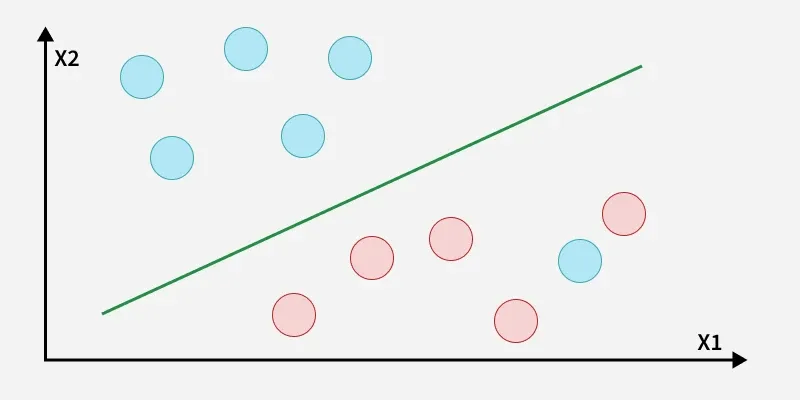

A soft margin allows for some misclassifications or violations of the margin to improve generalization. The SVM optimizes the following equation to balance margin maximization and penalty minimization:

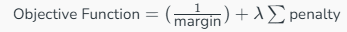

The penalty used for violations is often hinge loss which has the following behavior:

If a data point is correctly classified and within the margin there is no penalty (loss = 0).

If a point is incorrectly classified or violates the margin the hinge loss increases proportionally to the distance of the violation.

**What if data is not linearly separable?**

When data is not linearly separable i.e it can't be divided by a straight line, SVM uses a technique called kernels to map the data into a higher-dimensional space where it becomes separable. This transformation helps SVM find a decision boundary even for non-linear data.

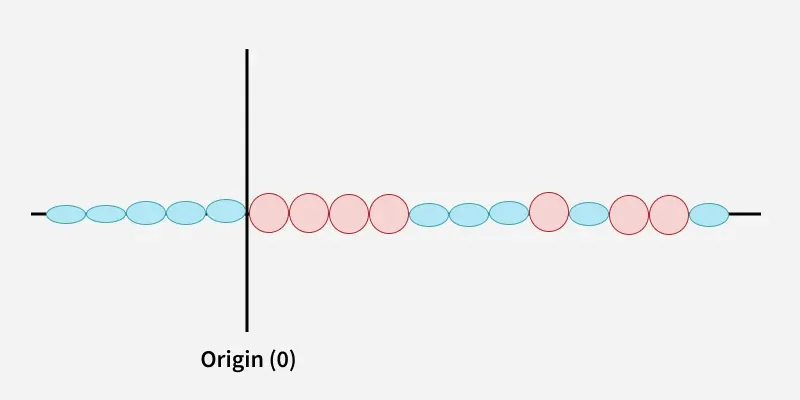

A kernel is a function that maps data points into a higher-dimensional space without explicitly computing the coordinates in that space. This allows SVM to work efficiently with non-linear data by implicitly performing the mapping. For example consider data points that are not linearly separable. By applying a kernel function SVM transforms the data points into a higher-dimensional space where they become linearly separable.

Linear Kernel: For linear separability.

Polynomial Kernel: Maps data into a polynomial space.

Radial Basis Function (RBF) Kernel: Transforms data into a space based on distances between data points.

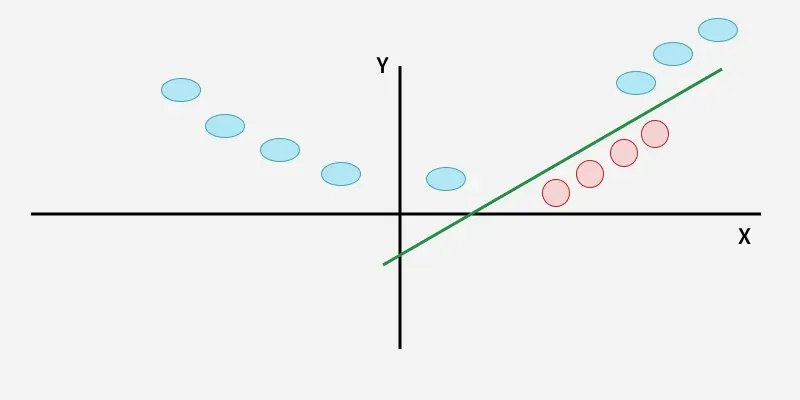

**Implementing SVM**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns; sns.set()

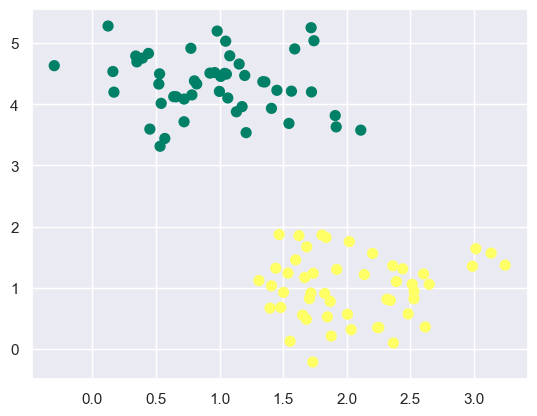

In [2]:
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=100, centers=2, random_state=0, cluster_std=0.50)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='summer');

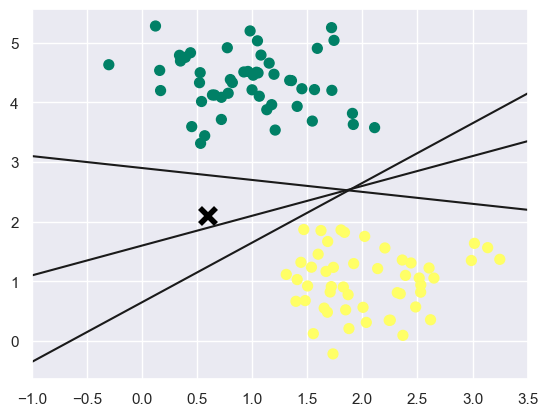

In [3]:
xfit = np.linspace(-1, 3.5)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='summer')
plt.plot([0.6], [2.1], 'x', color='black', markeredgewidth=4, markersize=12)
for m, b in [(1, 0.65), (0.5, 1.6), (-0.2, 2.9)]:
   plt.plot(xfit, m * xfit + b, '-k')
plt.xlim(-1, 3.5); 

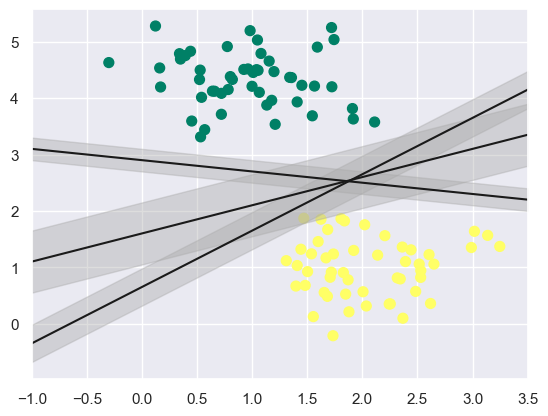

In [4]:
xfit = np.linspace(-1, 3.5)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='summer')
for m, b, d in [(1, 0.65, 0.33), (0.5, 1.6, 0.55), (-0.2, 2.9, 0.2)]:
  yfit = m * xfit + b
  plt.plot(xfit, yfit, '-k')
  plt.fill_between(xfit, yfit - d, yfit + d, edgecolor='none',
        color='#AAAAAA', alpha=0.4)
  plt.xlim(-1, 3.5);

In [5]:
from sklearn.svm import SVC # "Support vector classifier"
model = SVC(kernel='linear', C=1E10)
model.fit(X, y)

,C,10000000000.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [6]:
SVC(C=10000000000.0, cache_size=200, class_weight=None, coef0=0.0,
decision_function_shape='ovr', degree=3, gamma='auto_deprecated',
kernel='linear', max_iter=-1, probability=False, random_state=None,
shrinking=True, tol=0.001, verbose=False)

,C,10000000000.0
,kernel,'linear'
,degree,3
,gamma,'auto_deprecated'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [10]:
def decision_function(model, ax=None, plot_support=True):
   if ax is None:
      ax = plt.gca()
   xlim = ax.get_xlim()
   ylim = ax.get_ylim()
   x = np.linspace(xlim[0], xlim[1], 30)
   y = np.linspace(ylim[0], ylim[1], 30)
   Y, X = np.meshgrid(y, x)
   xy = np.vstack([X.ravel(), Y.ravel()]).T
   P = model.decision_function(xy).reshape(X.shape)
   ax.contour(X, Y, P, colors='k',
   levels=[-1, 0, 1], alpha=0.5,
   linestyles=['--', '-', '--'])

   if plot_support:
      ax.scatter(model.support_vectors_[:, 0],
      model.support_vectors_[:, 1],
      s=300, linewidth=1, facecolors='none');
      ax.set_xlim(xlim)
      ax.set_ylim(ylim)

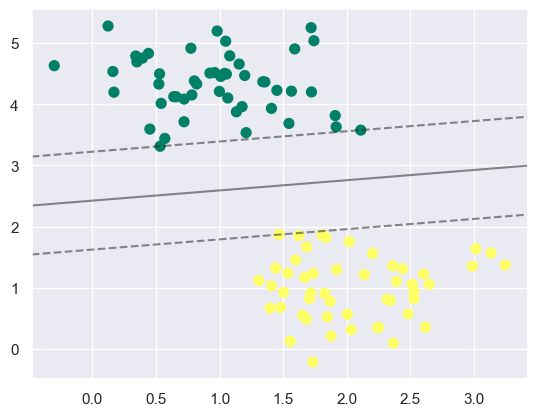

In [11]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='summer')
decision_function(model);

In [12]:
model.support_vectors_

array([[0.5323772 , 3.31338909],
       [2.11114739, 3.57660449],
       [1.46870582, 1.86947425]])

In [13]:
import pandas as pd
import numpy as np
from sklearn import svm, datasets
import matplotlib.pyplot as plt

In [14]:
iris = datasets.load_iris()

In [15]:
X = iris.data[:, :2]
y = iris.target

In [16]:
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
h = (x_max / x_min)/100
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
   np.arange(y_min, y_max, h))
X_plot = np.c_[xx.ravel(), yy.ravel()]

In [17]:
C = 1.0

Text(0.5, 1.0, 'Support Vector Classifier with linear kernel')

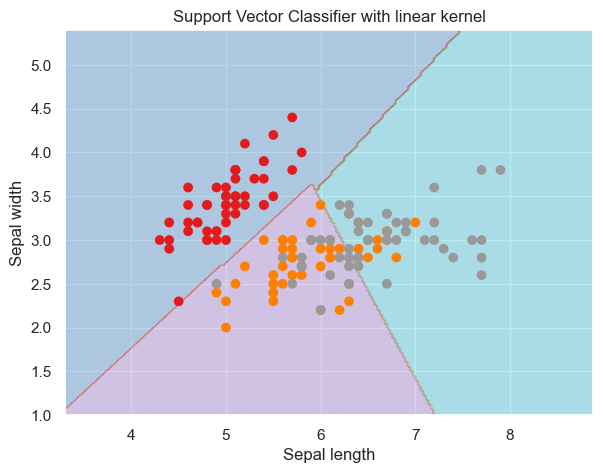

In [19]:
svc_classifier = svm.SVC(kernel='linear', C=C).fit(X, y)
Z = svc_classifier.predict(X_plot)
Z = Z.reshape(xx.shape)
plt.figure(figsize=(15, 5))
plt.subplot(121)
plt.contourf(xx, yy, Z, cmap=plt.cm.tab10, alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Set1)
plt.xlabel('Sepal length')
plt.ylabel('Sepal width')
plt.xlim(xx.min(), xx.max())
plt.title('Support Vector Classifier with linear kernel')

Text(0.5, 1.0, 'Support Vector Classifier with rbf kernel')

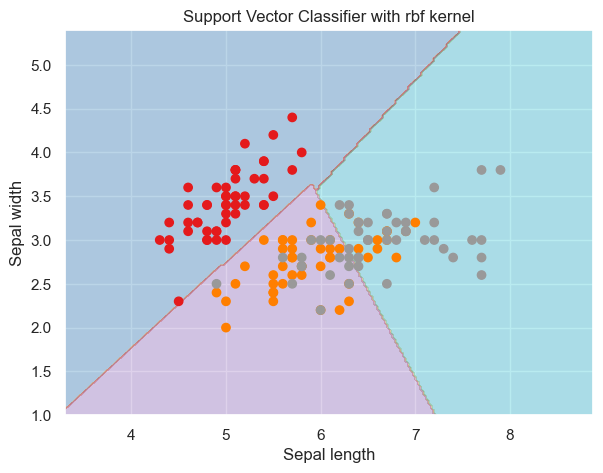

In [20]:
Svc_classifier = svm.SVC(kernel='rbf', gamma ='auto',C=C).fit(X, y)
Z = svc_classifier.predict(X_plot)
Z = Z.reshape(xx.shape)
plt.figure(figsize=(15, 5))
plt.subplot(121)
plt.contourf(xx, yy, Z, cmap=plt.cm.tab10, alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Set1)
plt.xlabel('Sepal length')
plt.ylabel('Sepal width')
plt.xlim(xx.min(), xx.max())
plt.title('Support Vector Classifier with rbf kernel')

Random search cv
Grid Search cv

In [23]:
#Tuning

from sklearn.model_selection import GridSearchCV
param_grid = {
   'C': [0.1, 1, 10, 100],
   'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
   'degree': [2, 3, 4],
   'coef0': [0.0, 0.1, 0.5],
   'gamma': ['scale', 'auto']
}

# create an SVM classifier
svm = SVC()

# perform grid search to find the best set of parameters
grid_search = GridSearchCV(svm, param_grid, cv=5)
grid_search.fit(X, y)
# print the best set of parameters and their accuracy
print("Best parameters:", grid_search.best_params_)
print("Best accuracy:", grid_search.best_score_)

Best parameters: {'C': 10, 'coef0': 0.0, 'degree': 4, 'gamma': 'auto', 'kernel': 'poly'}
Best accuracy: 0.8266666666666668
